# ChatGPT code

下一天预测销量：152.67


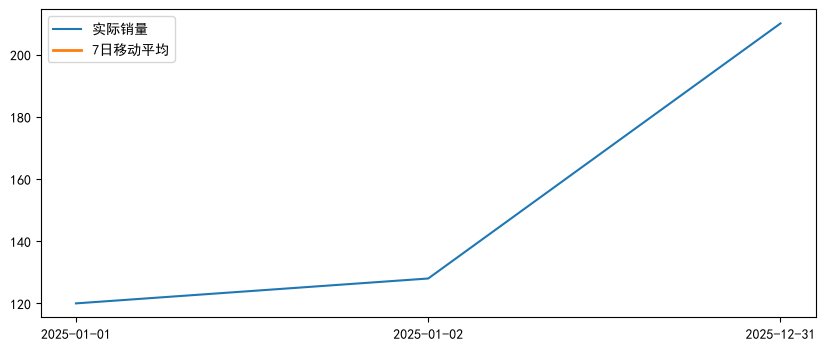

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft Yahei']

df = pd.read_csv("./data/sales.csv", parse_dates=["date"])
df = df.sort_values("date").set_index("date")

# 7日移动平均
df["ma_7"] = df["sales"].rolling(window=7).mean()

# 用最后7天的平均值预测下一天
next_day_pred = df["sales"].tail(7).mean()
print(f"下一天预测销量：{next_day_pred:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(df["sales"], label="实际销量")
plt.plot(df["ma_7"], label="7日移动平均", linewidth=2)
plt.legend()
plt.show()

# Gemini code

ADF 检验统计量: 1.3915
p-value: 0.9971
                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   60
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -271.289
Date:                Sat, 22 Aug 2026   AIC                            548.578
Time:                        17:18:18   BIC                            554.811
Sample:                    01-31-2019   HQIC                           551.011
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1304      0.423     -0.308      0.758      -0.959       0.698
ma.L1         -0.2598      0.412     -0.630      0.528      -1.068       0.548
sigma2       575.7

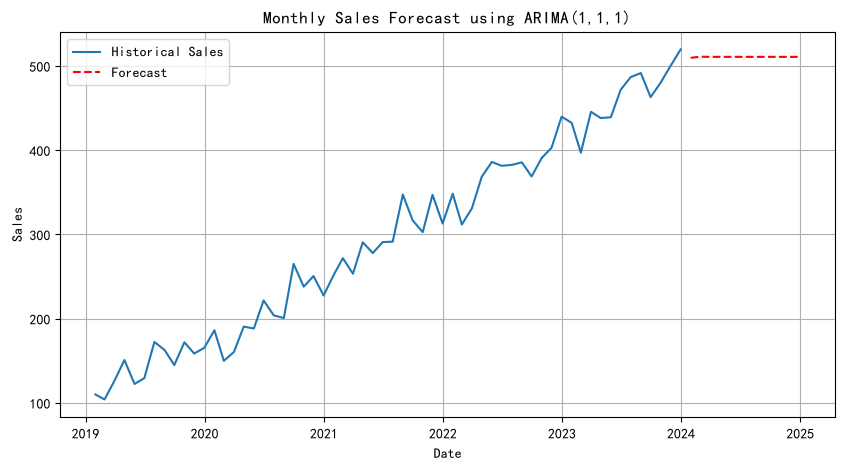

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# ==========================================
# 1. 模拟生成实际问题数据 (带趋势的销售额)
# ==========================================
np.random.seed(42)
dates = pd.date_range(start='2019-01-01', periods=60, freq='ME')
# 假设每个月基础销量递增，并伴随随机波动
sales = np.linspace(100, 500, 60) + np.random.normal(0, 20, 60)
df = pd.DataFrame({'Sales': sales}, index=dates)

# ==========================================
# 2. 平稳性检验 (ADF Test)
# ==========================================
# 数模论文中必须要有这一步，用来证明你需要进行差分 (d)
result = adfuller(df['Sales'])
print(f"ADF 检验统计量: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}") 
# 如果 p-value > 0.05，说明数据不平稳，需要差分。

# ==========================================
# 3. 构建与拟合 ARIMA(p, d, q) 模型
# ==========================================
# 假设经过 ACF 和 PACF 图的分析，我们选定 p=1, d=1, q=1
model = ARIMA(df['Sales'], order=(1, 1, 1))
model_fit = model.fit()

# 打印模型摘要 (可以直接截图放入数模论文的附录中)
print(model_fit.summary())

# ==========================================
# 4. 预测未来 12 个月
# ==========================================
forecast = model_fit.forecast(steps=12)

# ==========================================
# 5. 可视化结果 (数模必备)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Sales'], label='Historical Sales')
plt.plot(forecast.index, forecast, color='red', label='Forecast', linestyle='--')
plt.title('Monthly Sales Forecast using ARIMA(1,1,1)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()